# 03 — Feature engineering, modeling & honest evaluation

The plan, fixed **before** looking at any test results:

1. **Features:** rolling "form" statistics computed only from earlier matches (no leakage).
2. **Split:** train on 2015-16 → 2023-24, hold out the two most recent seasons (2024-25, 2025-26) as a final test set we touch exactly once.
3. **Model selection:** compare candidates using time-series cross-validation *inside the training data* — the test set plays no role in choosing.
4. **Evaluation:** accuracy *and* log loss, per-class metrics, calibration, and error analysis — benchmarked against a naive baseline (floor) and the bookmakers (ceiling).

In [1]:
import sys
sys.path.append("..")

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, log_loss
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.data import add_implied_probs, load_match_table
from src.features import FEATURE_COLS, build_features

sns.set_theme(style="whitegrid")
FIG_DIR = Path("../figures")
CLASSES = ["H", "D", "A"]  # fixed column order used everywhere below

matches = add_implied_probs(load_match_table())

## 1. Features: what the model is allowed to know

At prediction time (before kick-off) we know each team's *history*, nothing else. [`src/features.py`](../src/features.py) computes, for **each side**:

| Feature | What it captures | Why (from EDA) |
|---|---|---|
| `ppg_last5` | points/game, last 5 matches | recent form |
| `ppg_last38` | points/game, last ~season | underlying team strength |
| `gf_last5`, `ga_last5` | goals scored/conceded per game, last 5 | attack & defence separately |
| `sot_last5` | shots on target per game, last 5 | performance signal beyond goals (less lucky) |
| `ppg_venue_last5` | points/game in last 5 matches *at this venue* | home advantage is team-specific (notebook 02) |
| `rest_days` | days since previous match, capped at 30 | fixture congestion |

**The leakage guard.** Every rolling window is applied *after* `.shift(1)`, so the window for a match covers only strictly earlier matches. The in-match statistics from notebook 01 (shots, corners) appear **only** inside these historical windows — never from the match being predicted.

Because promoted teams enter the dataset with no history, their first few matches have undefined features. We drop those rows rather than invent values.

In [2]:
features = build_features(matches)
data = features.dropna(subset=FEATURE_COLS)
print(f"usable matches: {len(data)} of {len(features)} (dropped {len(features) - len(data)} with insufficient history)")
data[["date", "home_team", "away_team", "result"] + FEATURE_COLS[:4]].tail(3)

usable matches: 3942 of 4180 (dropped 238 with insufficient history)


,date,home_team,away_team,result,home_ppg_last5,home_ppg_last38,home_gf_last5,home_ga_last5
4177,2026-05-24,Brighton,Man United,A,1.4,1.473684,1.8,1.2
4178,2026-05-24,Fulham,Newcastle,H,1.0,1.289474,0.4,1.0
4179,2026-05-24,West Ham,Leeds,H,0.8,1.026316,0.6,1.6


In [3]:
# Leakage spot-check: recompute one team's ppg_last5 by hand and compare.
team = "Arsenal"
tm = features[(features["home_team"] == team) | (features["away_team"] == team)].copy()
tm["pts"] = [
    {"H": 3, "D": 1, "A": 0}[r] if h == team else {"A": 3, "D": 1, "H": 0}[r]
    for h, r in zip(tm["home_team"], tm["result"])
]
row = tm.iloc[20]
by_hand = tm.iloc[15:20]["pts"].mean()  # matches 16-20: strictly before match 21
from_feature = row["home_ppg_last5"] if row["home_team"] == team else row["away_ppg_last5"]
assert abs(by_hand - from_feature) < 1e-9
print(f"{team}, match 21: by hand = {by_hand:.3f}, feature = {from_feature:.3f} — no leakage \u2714")

Arsenal, match 21: by hand = 2.400, feature = 2.400 — no leakage ✔


## 2. A time-based split, not a random one

A random split would be subtly dishonest here: the model would train on matches from May 2025 and be "tested" on matches from January 2025 — predicting the past from the future. Form features make it worse: a January match's features summarize December results the model may have trained on directly.

So: **train = 2015-16 → 2023-24, test = 2024-25 + 2025-26**, and the same rule inside training — cross-validation uses `TimeSeriesSplit`, which always trains on the past and validates on the future.

In [4]:
TEST_SEASONS = ["2024-25", "2025-26"]
train = data[~data["season"].isin(TEST_SEASONS)]
test = data[data["season"].isin(TEST_SEASONS)]
X_train, y_train = train[FEATURE_COLS], train["result"]
X_test, y_test = test[FEATURE_COLS], test["result"]
print(f"train: {len(train)} matches ({train['season'].min()} → {train['season'].max()})")
print(f"test:  {len(test)} matches ({', '.join(TEST_SEASONS)}) — untouched until section 4")

train: 3192 matches (2015-16 → 2023-24)
test:  750 matches (2024-25, 2025-26) — untouched until section 4


## 3. Candidate models, and how we choose

- **`DummyClassifier(strategy="prior")`** — always predicts the training class frequencies. Not a real model; it's the floor that tells us whether the features contain any signal at all.
- **Logistic regression** (with feature standardization) — the workhorse linear model. Interpretable coefficients, naturally produces probabilities, hard to overfit with only 14 features.
- **Histogram gradient boosting** — the standard "strong tabular model". Captures non-linearities and feature interactions, *if* there are any worth capturing; we tune its two most important knobs with a small grid.

**Selection metric: log loss, not accuracy.** A football model's real output is probabilities ("58% home win"), and log loss rewards honest, well-calibrated probabilities while accuracy only checks the top pick. All selection happens via `TimeSeriesSplit` CV on the training years only.

In [5]:
tscv = TimeSeriesSplit(n_splits=4)

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
lr_cv = -cross_val_score(logreg, X_train, y_train, cv=tscv, scoring="neg_log_loss", n_jobs=-1)

hgb_grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=0),
    {"learning_rate": [0.03, 0.1], "max_leaf_nodes": [7, 15, 31]},
    cv=tscv, scoring="neg_log_loss", n_jobs=-1,
).fit(X_train, y_train)

print(f"logistic regression   CV log loss: {lr_cv.mean():.4f}")
print(f"gradient boosting     CV log loss: {-hgb_grid.best_score_:.4f}  (best: {hgb_grid.best_params_})")
print(f"\n→ cross-validation prefers LOGISTIC REGRESSION — it becomes our primary model")

logistic regression   CV log loss: 0.9812
gradient boosting     CV log loss: 0.9946  (best: {'learning_rate': 0.03, 'max_leaf_nodes': 7})

→ cross-validation prefers LOGISTIC REGRESSION — it becomes our primary model


Cross-validation prefers the *simpler* model. That's not an anticlimax — it's information: with ~3,200 training matches and features that already summarize the relevant history, there isn't enough signal left for a flexible model to find interactions that generalize; it mostly finds noise. We keep the tuned boosting model around to verify this holds on the test set.

## 4. The final exam: two unseen seasons

Four contestants on the same 750 matches: the dummy floor, both models, and Bet365's own probabilities (margin removed).

In [6]:
logreg.fit(X_train, y_train)
dummy = DummyClassifier(strategy="prior").fit(X_train, y_train)

def as_frame(proba, model_classes):
    """Probabilities in a fixed H/D/A column order, whatever the model's internal order."""
    return pd.DataFrame(proba, columns=list(model_classes), index=y_test.index)[CLASSES]

contestants = {
    "baseline: class frequencies": as_frame(dummy.predict_proba(X_test), dummy.classes_),
    "logistic regression": as_frame(logreg.predict_proba(X_test), logreg.classes_),
    "gradient boosting (tuned)": as_frame(hgb_grid.predict_proba(X_test), hgb_grid.best_estimator_.classes_),
    "bookmaker (Bet365)": test[["book_prob_home", "book_prob_draw", "book_prob_away"]].set_axis(CLASSES, axis=1),
}

# sklearn's log_loss requires probability columns in lexicographic label
# order (A, D, H) — passing them as H/D/A silently miscomputes the score.
SORTED = sorted(CLASSES)

results = pd.DataFrame({
    name: {
        "accuracy": accuracy_score(y_test, proba.idxmax(axis=1)),
        "log loss": log_loss(y_test, proba[SORTED], labels=SORTED),
    }
    for name, proba in contestants.items()
}).T
results.round(4)

,accuracy,log loss
baseline: class frequencies,0.4187,1.0817
logistic regression,0.5093,1.0176
gradient boosting (tuned),0.4853,1.0410
bookmaker (Bet365),0.5160,0.9949


**Reading the table:**

- Logistic regression reaches **~51% accuracy** — far above the 42% floor, and within **one percentage point of the bookmakers** on the same matches. On log loss the gap is 1.018 vs 0.995: real, but small.
- Gradient boosting is worse on the test set too (~48.5%) — the cross-validation verdict from section 3 was correct, and we avoided shipping the flashier, worse model.
- Note the bookmakers themselves only hit ~52% here, below their 55% long-run average — the post-COVID seasons with weakened home advantage (notebook 02) are genuinely harder to predict, for everyone.

## 5. Beyond accuracy: where is the model right and wrong?

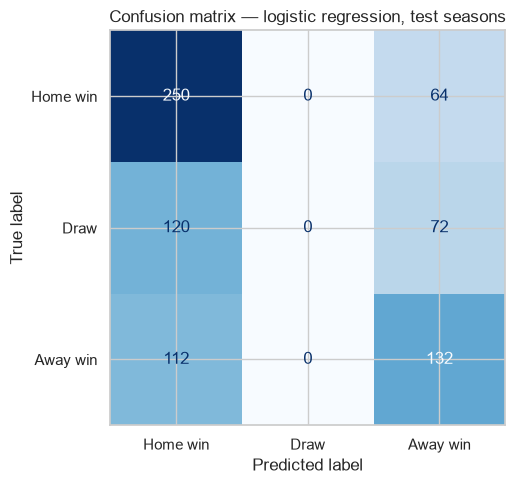

              precision    recall  f1-score   support

    Home win      0.519     0.796     0.628       314
        Draw      0.000     0.000     0.000       192
    Away win      0.493     0.541     0.516       244

    accuracy                          0.509       750
   macro avg      0.337     0.446     0.381       750
weighted avg      0.377     0.509     0.431       750



In [7]:
proba = contestants["logistic regression"]
pred = proba.idxmax(axis=1)

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, labels=CLASSES,
    display_labels=["Home win", "Draw", "Away win"],
    cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title("Confusion matrix — logistic regression, test seasons")
fig.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_test, pred, labels=CLASSES,
                            target_names=["Home win", "Draw", "Away win"], digits=3, zero_division=0))

**The draw column is empty — 0 draws predicted in 750 matches, so draw recall is 0.000.** Notebook 02 predicted exactly this: a draw's probability never exceeds 1/3, so a most-likely-outcome classifier never picks it. The model isn't blind to draws — it prices them at 20-30% — it just never ranks one first. (The bookmakers' favourite has *never* been a draw either, in 4,180 matches.) This is why reporting only "51% accuracy" would hide the most interesting behaviour of the model.

**Are the probabilities themselves honest?** Calibration check: when the model says "60% home win", how often does the home team actually win?

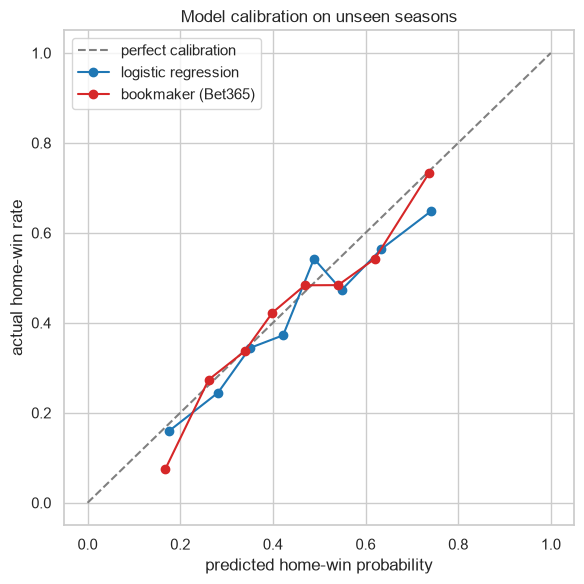

In [8]:
def calibration_points(probs, outcomes, n_bins=8):
    bins = pd.qcut(probs, n_bins, duplicates="drop")
    grouped = pd.DataFrame({"p": probs, "hit": (outcomes == "H").astype(int)}).groupby(bins, observed=True)
    return grouped["p"].mean(), grouped["hit"].mean()

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
for name, color in [("logistic regression", "#1f77b4"), ("bookmaker (Bet365)", "#d62728")]:
    x, y = calibration_points(contestants[name]["H"], y_test)
    ax.plot(x, y, marker="o", color=color, label=name)
ax.set_xlabel("predicted home-win probability")
ax.set_ylabel("actual home-win rate")
ax.set_title("Model calibration on unseen seasons")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "model_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Error analysis

Two questions: does the model know *when* it's confident, and what do its worst misses look like?

In [9]:
analysis = test.copy()
analysis["pred"] = pred
analysis["confidence"] = proba.max(axis=1)
analysis["correct"] = analysis["pred"] == analysis["result"]
analysis["p_actual"] = [proba.loc[i, r] for i, r in zip(analysis.index, analysis["result"])]

buckets = pd.cut(analysis["confidence"], [0, 0.45, 0.55, 0.7, 1.0],
                 labels=["toss-up (<45%)", "lean (45-55%)", "confident (55-70%)", "strong (>70%)"])
analysis.groupby(buckets, observed=True).agg(
    matches=("correct", "size"), accuracy=("correct", "mean")
).round(3)

,matches,accuracy
confidence,,
toss-up (<45%),204,0.456
lean (45-55%),245,0.457
confident (55-70%),217,0.548
strong (>70%),84,0.690


In [10]:
# The ten matches where the model gave the actual outcome the least probability.
cols = ["date", "home_team", "away_team", "home_goals", "away_goals", "p_actual", "odds_home", "odds_away"]
upsets = analysis.nsmallest(10, "p_actual")[cols].copy()
upsets["date"] = upsets["date"].dt.date
upsets.round(3)

,date,home_team,away_team,home_goals,away_goals,p_actual,odds_home,odds_away
3677,2025-02-22,Arsenal,West Ham,0,1,0.068,1.27,10.00
3526,2024-11-10,Tottenham,Ipswich,1,2,0.084,1.25,9.00
3606,2024-12-30,Ipswich,Chelsea,2,0,0.085,6.50,1.42
3454,2024-09-14,Liverpool,Nott'm Forest,0,1,0.087,1.22,12.00
4055,2026-02-11,Crystal Palace,Burnley,2,3,0.088,1.57,6.25
3595,2024-12-26,Chelsea,Fulham,1,2,0.095,1.48,6.00
3882,2025-10-25,Chelsea,Sunderland,1,2,0.102,1.36,9.00
3878,2025-10-19,Liverpool,Man United,1,2,0.103,1.60,5.00
3577,2024-12-15,Man City,Man United,1,2,0.105,1.57,5.00
3811,2025-08-23,Man City,Tottenham,0,2,0.107,1.48,6.25


**Findings.** Confidence is meaningful: toss-ups and leans land around 46%, but accuracy jumps to ~55% on confident calls and **~69% when the model is strongly confident (>70%)** — the probability output is genuinely informative, which is exactly what the Streamlit app should display. And the worst misses are *shock results* — Arsenal losing at home to West Ham at odds of 1.27, Manchester City losing the derby, promoted Ipswich beating Chelsea. The bookmaker odds columns show they didn't see these coming either. These aren't model failures to engineer away; they're the irreducible randomness that caps this problem near ~55%.

## 7. What did the model actually learn?

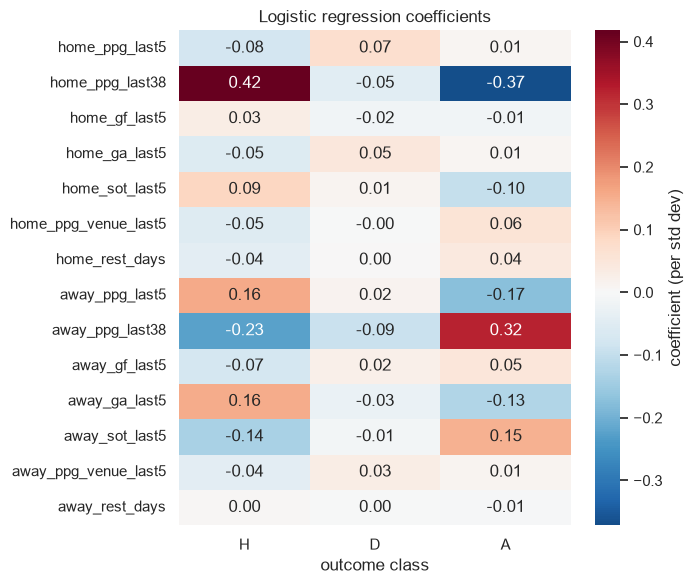

In [11]:
coefs = pd.DataFrame(
    logreg[-1].coef_, index=logreg[-1].classes_, columns=FEATURE_COLS
).T[["H", "D", "A"]]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(coefs, cmap="RdBu_r", center=0, annot=True, fmt=".2f", ax=ax,
            cbar_kws={"label": "coefficient (per std dev)"})
ax.set_title("Logistic regression coefficients")
ax.set_xlabel("outcome class")
fig.tight_layout()
fig.savefig(FIG_DIR / "lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

**The dominant features are `home_ppg_last38` and `away_ppg_last38`** — season-long strength — with much larger coefficients than the 5-match form features. *"Form is temporary, class is permanent"* turns out to be measurable: who a team fundamentally is matters far more than their last month.

(One honest caveat: these features are correlated with each other — a team with high `ppg_last38` usually has decent `ppg_last5` too — so individual coefficient signs on the smaller features shouldn't be over-interpreted. The heatmap shows the big picture, not fourteen independent facts.)

## 8. Ship it: save the model for the app

In [12]:
artifact = {
    "model": logreg,
    "feature_cols": FEATURE_COLS,
    "classes": CLASSES,
    "trained_through": str(data["date"].max().date()),
    "test_metrics": results.loc["logistic regression"].round(4).to_dict(),
}
path = Path("../models/match_predictor.joblib")
joblib.dump(artifact, path)
print(f"saved {path} ({path.stat().st_size / 1024:.0f} KB)")

saved ../models/match_predictor.joblib (3 KB)


## 9. Summary & limitations

**What we can honestly claim:** using only pre-match form features, a logistic regression predicts Premier League results at ~51% on two fully unseen seasons — clearly above the 42-44% naive floor, within ~1 point of the bookmakers' accuracy, with meaningful (if slightly less sharp) probabilities.

**Limitations, in order of how much they probably cost us:**

1. **No player-level information** — injuries, suspensions, transfers, and rotation are invisible to team-level rolling stats. This is likely most of the remaining gap to the bookmakers.
2. **Draws are never predicted** — structural (no outcome-probability model fixes this), but a betting-oriented user would want the draw *probability* surfaced, which the app does.
3. **Team identity is only implicit** — a promoted team and a relegated one can have similar early rolling stats; features like squad value or Elo ratings would sharpen this.
4. **One league, one bookmaker** — conclusions may not transfer to leagues with different draw rates or home advantages.

**Next:** the Streamlit app — pick any two current teams and see the model's probabilities next to each team's form.